In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import random

In [2]:
# Read train, val, test
train_df = pd.read_csv("dataset/LSTM/train_lstm.csv")
val_df = pd.read_csv("dataset/LSTM/val_lstm.csv")
test_df = pd.read_csv("dataset/LSTM/test_lstm.csv")

In [3]:
train_df.head()

,period,idr_usd,inflation_rate,interest_rate,cond_vol
0,2015-01-05,12652.0,6.96,7.75,0.005032
1,2015-01-06,12721.0,6.96,7.75,0.005578
2,2015-01-07,12796.0,6.96,7.75,0.005540
3,2015-01-08,12795.0,6.96,7.75,0.005552
4,2015-01-09,12703.0,6.96,7.75,0.005242


In [4]:
val_df.head()

,period,idr_usd,inflation_rate,interest_rate,cond_vol
0,2022-01-03,14349.39,2.18,3.5,0.002599
1,2022-01-04,14341.35,2.18,3.5,0.002518
2,2022-01-05,14381.55,2.18,3.5,0.002442
3,2022-01-06,14436.83,2.18,3.5,0.002527
4,2022-01-07,14467.98,2.18,3.5,0.002729


In [5]:
test_df.tail()

,period,idr_usd,inflation_rate,interest_rate,cond_vol
472,2024-12-23,16351.35,1.57,6.0,0.0
473,2024-12-24,16239.80,1.57,6.0,0.0
474,2024-12-27,16289.04,1.57,6.0,0.0
475,2024-12-30,16332.25,1.57,6.0,0.0
476,2024-12-31,16242.81,1.57,6.0,0.0


## GARCH-LSTM (Features: Raw Price, GARCH-based Volatility, Macro Data)

## Scaling

In [3]:
#Scaling
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

features = ['idr_usd', 'cond_vol', 'inflation_rate', 'interest_rate']

# Buat scaler untuk input fitur
scaler_X = MinMaxScaler(feature_range=(0,1))

# Fit scaler hanya pada TRAINING data (hindari data leakage)
scaler_X.fit(train_df[features])

# Transform train, val, test pakai scaler yg sama
train_scaled = scaler_X.transform(train_df[features])
val_scaled   = scaler_X.transform(val_df[features])
test_scaled  = scaler_X.transform(test_df[features])

# Jika target yang diprediksi hanya harga (idr_myr)
scaler_y = MinMaxScaler(feature_range=(0,1))
scaler_y.fit(train_df[['idr_usd']])

y_train_scaled = scaler_y.transform(train_df[['idr_usd']])
y_val_scaled   = scaler_y.transform(val_df[['idr_usd']])
y_test_scaled  = scaler_y.transform(test_df[['idr_usd']])

## Windowing

In [4]:
def create_windowed_data_multivariate(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30

X_train, y_train = create_windowed_data_multivariate(train_scaled, WINDOW_SIZE)
X_val, y_val     = create_windowed_data_multivariate(val_scaled, WINDOW_SIZE)
X_test, y_test   = create_windowed_data_multivariate(test_scaled, WINDOW_SIZE)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1696, 30, 4)
y_train shape: (1696,)


## Data Reshaping

In [5]:
# Input Features (X)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 4))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 4))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 4))

print("X_train reshaped:", X_train.shape)
print("X_val reshaped:", X_val.shape)
print("X_test reshaped:", X_test.shape)

# Target (y) -> 1 output
y_train = y_train.reshape(-1, 1)
y_val   = y_val.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

print("y_train reshaped:", y_train.shape)
print("y_val reshaped:", y_val.shape)
print("y_test reshaped:", y_test.shape)

X_train reshaped: (1696, 30, 4)
X_val reshaped: (216, 30, 4)
X_test reshaped: (447, 30, 4)
y_train reshaped: (1696, 1)
y_val reshaped: (216, 1)
y_test reshaped: (447, 1)


## Baseline Model Implementation

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

base_model = Sequential([
    LSTM(50, input_shape=(WINDOW_SIZE, 4)),  # units default 50, features = 4
    Dense(1)  # output : prediksi 1 nilai
])

# Compile model
base_model.compile(optimizer=Adam(), loss='mse')

# Fit model using default parameter
history_base = base_model.fit(
    X_train, y_train, # data training
    epochs=50, # dataset is iterated for 50 times
    batch_size=32, # update weights tiap 32 data
    validation_data=(X_val, y_val), # monitor performa model saat training -> using data validation
    verbose=1
)

# Evaluasi base model
base_eval = base_model.evaluate(X_test, y_test, verbose=0)
print("Base model test MSE:", base_eval)

C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0172 - val_loss: 0.0142
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0020 - val_loss: 0.0056
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.5718e-04 - val_loss: 0.0015
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.8719e-04 - val_loss: 0.0015
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.3047e-04 - val_loss: 0.0015
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.8326e-04 - val_loss: 0.0015
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.4282e-04 - val_loss: 0.0015
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 1

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_test_true = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler_y.inverse_transform(base_model.predict(X_test))

# RMSE, MAE, MAPE, R2 untuk test set
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae = mean_absolute_error(y_test_true, y_test_pred_original)
r2 = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Test R2: {r2:.6f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Test RMSE: 92.592462
Test MAE: 76.569134
Test R2: 0.954790


## Hyperparameter Tuning (HPT)

In [6]:
from tensorflow.keras.models import Sequential
from kerastuner.tuners import RandomSearch
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

def build_model(hp):
    model = Sequential()
    
    # Hyperparameter: jumlah unit LSTM
    units = hp.Int('units', min_value=32, max_value=128, step=16)
    model.add(LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 4)))

    # Hyperparameter: Dropout
    dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.2, 0.4])
    model.add(Dropout(dropout_rate))
    
    # Hyperparameter: learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    
    return model

#TUNER SETUP
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=2,
    directory='my_dir',
    project_name='garch-lstm-4f_tuning'
)

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# EXECUTE TUNING
tuner.search(
    X_train, y_train,
    epochs=600,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# GET BEST MODEL
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters.values)

# SUMMARY
best_model.summary()

Trial 20 Complete [00h 03m 34s]
val_loss: 0.00017913906776811928

Best val_loss So Far: 0.00014748634566785768
Total elapsed time: 06h 28m 48s
Best Hyperparameters:
{'units': 112, 'dropout_rate': 0.2, 'learning_rate': 0.01}


C:\Users\Aileen\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 112)                 │          52,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             113 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,529 (205.19 KB)

 Trainable params: 52,529 (205.19 KB)

 Non-trainable params: 0 (0.00 B)

## Final Training Model

In [8]:
#Retraining model using train + val sets
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Combine train & val sets
final_train_data = np.concatenate((train_scaled, val_scaled))
X_train_new, y_train_new = create_windowed_data_multivariate(final_train_data, WINDOW_SIZE)

# Test data tetap dipakai untuk evaluasi
X_test, y_test = create_windowed_data_multivariate(test_scaled, WINDOW_SIZE)

#Best parameters
units = 112
learning_rate = 0.01
dropout_rate = 0.2

model = Sequential([
    LSTM(units, return_sequences=False, input_shape=(WINDOW_SIZE, 4)),
    Dropout(dropout_rate),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# CALLBACK FOR EARLY STOPPING
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_new, y_train_new,
    epochs=600,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Prediksi
y_train_pred = model.predict(X_train_new)
y_test_pred = model.predict(X_test)

# Kembali ke skala asli
y_train_true = scaler_y.inverse_transform(y_train_new.reshape(-1,1))
y_train_pred_original = scaler_y.inverse_transform(y_train_pred)

y_test_true = scaler_y.inverse_transform(y_test.reshape(-1,1))
y_test_pred_original = scaler_y.inverse_transform(y_test_pred)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
mae = mean_absolute_error(y_test_true, y_test_pred_original)
r2 = r2_score(y_test_true, y_test_pred_original)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R2: {r2:.4f}")

Epoch 1/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0400
Epoch 2/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029
Epoch 3/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0024
Epoch 4/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0019
Epoch 5/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014
Epoch 6/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014
Epoch 7/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011
Epoch 8/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0010    
Epoch 9/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011
Epoch 10/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.0252e-04
Epoch 11/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.8029e-04
Epoch 12/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.1910e-04
Epoch 13/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.2601e-04
Epoch 14/600
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.9382e-04
Epoch 15/600
31/31 ━━━━━━━━━━━━━━

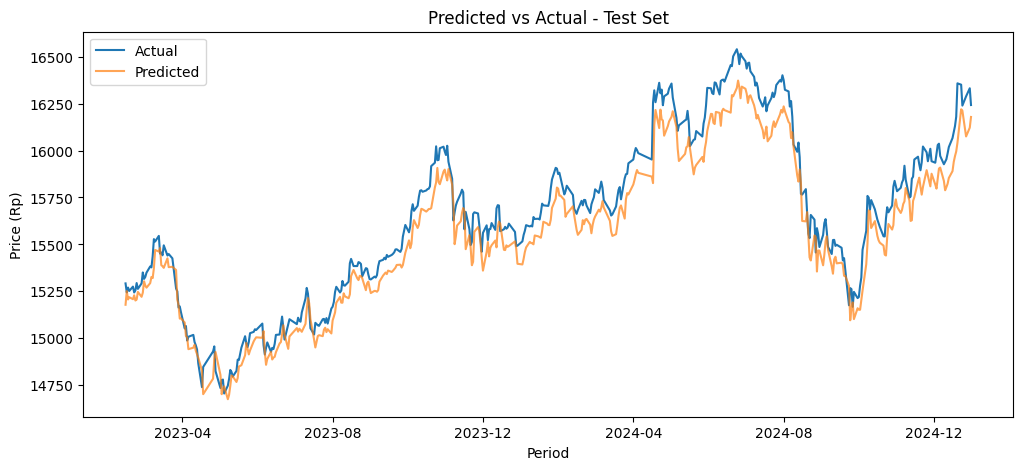

In [9]:
import matplotlib.dates as mdates

test_dates = pd.to_datetime(test_df['period'].iloc[WINDOW_SIZE:])

plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test_true, label='Actual')
plt.plot(test_dates, y_test_pred_original, label='Predicted', alpha=0.7)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # format YYYY-MM

plt.title("Predicted vs Actual - Test Set")
plt.xlabel("Period")
plt.ylabel("Price (Rp)")
plt.legend()

## Out-of-sample Performance

The GARCH-LSTM model with **price, volatility, and two macroeconomic features** was evaluated on the **unseen test set (2023–2024)**. Hyperparameter tuning (HPT) was attempted with an increased number of trials to optimize model performance.

- **Baseline Model Performance**  
  - Test RMSE: 92.59  
  - Test MAE: 76.57  
  - Test R²: 0.9548  

- **Tuned Model Performance**  
  - Test RMSE: 122.26  
  - Test MAE: 106.71  
  - Test R²: 0.9212  

**Observation:**  
Despite increasing HPT trials (from 15 to 20), the tuned model **did not outperform the default configuration**. In fact, the test metrics worsened slightly. This suggests that the default parameters were already suitable for this 4-feature setup.

**Key Takeaways:**  
- Not all models benefit from hyperparameter tuning.  
- The default model can be retained as the **final evaluation model**, while the HPT attempt is documented as part of the exploration process.
- **Adding macroeconomic features did not improve the model since the USD/IDR volatility is largely driven by global shocks.**

In [10]:
# Simpan the best GARCH-LSTM model (tuned)
model.save("model/best_model_garch-lstm_4features.keras")
print("💾 Model saved as best_model_garch-lstm_4features.keras")

💾 Model saved as best_model_garch-lstm_4features.keras
